# Alias Sampling Setup Tutorial

Alias sampling is a technique for implementing arbitrary state preparation for quantum algorithms that only need to use the arbitrary state as control (e.g., $\mathrm{PREP-SEL-PREP^+}$).

given a normalized list of probabilities $\vec{a} = [a_0, a_1, ..., a_{2^n - 1}]$, prepare the following $n$-qubit state with some garbage states $|g\rangle$ entangled with the desired states:

$$ \ket{\psi} = \sum_{i = 0}^{2^n - 1}\sqrt{a_i}\ket{i}|g_i\rangle $$

For our state prep to work, we need a few magic ingredients:

1. A uniform superposition preparation subroutine
2. A QROM data loader
3. Some utility functions to build the alias and threshold values.

All of these, along with the `Qubrick` that builds the final circuit, are provided in Workbench Algorithms. For interested parties, the technique is an implementation of the circuit in Fig. 11 in [Google's encoding electronic spectra paper.](https://arxiv.org/pdf/1805.03662.pdf)

In [1]:
import numpy as np

# import QPU setups from workbench
from psiqworkbench import QPU, Qubits

# import QROM instances
from workbench_algorithms import (
    USP,
    DataLookupClean,
    SwapUp,
    SelectNaive, # using full multi-control Toffoli gates for easier visualization & classical simulation
    BinaryTreeSelect, # using the optimized elbows from Babbush et al. and LKS's SELECT-SWAP trick for better quantum resource estimation
)

# import experimental alias sampling Qubrick
from workbench_algorithms.experimental.subroutines import AliasSampling

# import utility functions
from workbench_algorithms.experimental.utils import (
    AliasSamplingStatePrepData,
    alias_sampling_get_b_from_epsilon,
    l2_normalize,
    l2_norm_diff,
)

Let's first setup a small instance where we can run the quantum circuit simulator.

We want the `AliasSampling` circuit to create a 3-qubit state arbitrary state for us (all amplitudes are real positive).

In [2]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]
print(coeffs)

[0.3745401188473625, 0.9507143064099162, 0.7319939418114051, 0.5986584841970366, 0.15601864044243652, 0.15599452033620265, 0.05808361216819946, 0.8661761457749352]


We can then compute the normalized probabilities array by:

In [3]:
probabilities = [c ** 2 for c in coeffs]
normalized_prob = np.array(probabilities) / sum(probabilities)
print(list(normalized_prob))

[np.float64(0.05118493490444534), np.float64(0.3297961078105638), np.float64(0.19550615782028644), np.float64(0.1307686832760824), np.float64(0.00888174797406119), np.float64(0.008879001992626557), np.float64(0.0012309848307578328), np.float64(0.2737523813911765)]


By definition from Eq. 34 in the Babbush et al. paper, we will create a quantum circuit that perform the following operation:

$|0\rangle^{\otimes(1+2\mu+2\log{L})} \rightarrow \sum_{l=0}^{L-1}\sqrt{\tilde{\rho_{l}}}|l\rangle|\mathrm{temp}_l\rangle$

where $\sqrt{\rho_{l}}$ are each amplitude of the normalized input array (this way $|\psi\rangle = \sum_{l=0}^{L-1}\sqrt{\tilde{\rho_{l}}}|l\rangle$).

Oftentimes we can not create the quantum state that matches the exact input state $|\psi\rangle$, but can hope to get a quantum state $|\psi'\rangle$ that is somehow close enough to it. 

We can use a $\epsilon$ number to quantify how close we are:

$|||\psi\rangle - |\psi'\rangle|| < \epsilon$

Therefore, given a target $\epsilon$, we can calculate the required precision bit `b` (the same as $\mu$) via the `alias_sampling_get_b_from_epsilon()` function:

In [4]:
epsilon = 5e-2
b = alias_sampling_get_b_from_epsilon(coeffs, epsilon) # try mannually set b to some other number and see how it will change things!
print(b)

4


Now let's set up the quantum circuit!

We will first create an `AliasSamplingStatePrepData` object to store all the data needed.

In [5]:
data = AliasSamplingStatePrepData(coeffs, b)
print(data)

NumericAliasSamplingStatePrepData(coeffs=[0.3745401188473625, 0.9507143064099162, 0.7319939418114051, 0.5986584841970366, 0.15601864044243652, 0.15599452033620265, 0.05808361216819946, 0.8661761457749352], bits_of_precision=4, lambda_val=None, error_param=None)


Next, we will allocate the required number of qubits for the QPU.

In [6]:
qc = QPU()
num_prep = n
num_alias = n
num_keep = b
num_coin = b
num_comp_anc = b
num_qrom = (num_alias + num_keep)
num_qubits = num_prep + num_qrom + num_coin + num_comp_anc
qc.reset(num_qubits) 

We now set up the QROM instance (here we pick the naive version for the purpose of demostration) and the `USP` intance to produce the $\mathrm{UNIFORM_L}$ shown in Fig. 11 in Babbush et al.

In [7]:
qrom_instance = DataLookupClean(select=SelectNaive(), swap_up=SwapUp()) # use all clean qubits
usp_instance = USP()

Now we are ready to set up the `AliasSampling` object and construct the entire quantum circuit.

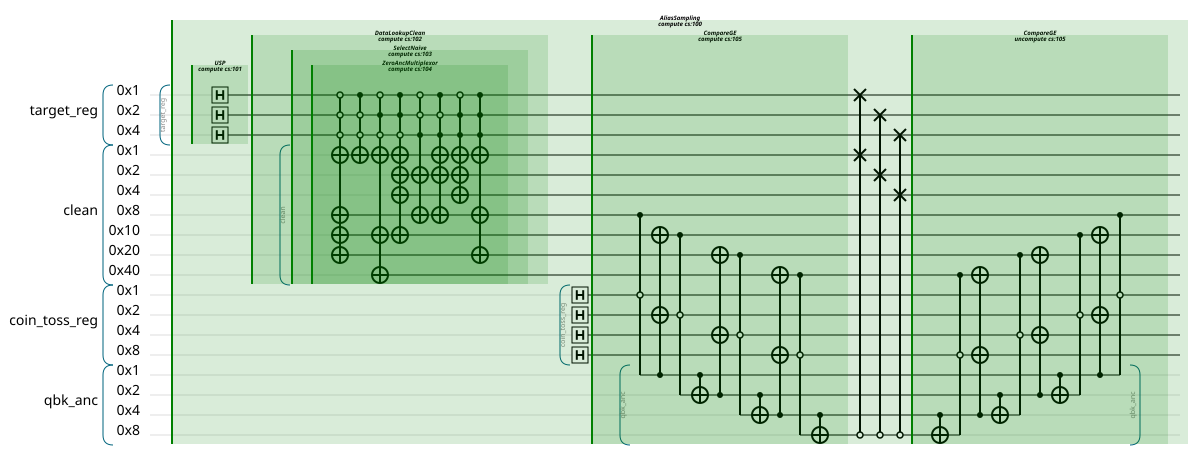

In [8]:
state_prep = AliasSampling(qrom=qrom_instance, usp=usp_instance)

target_reg = Qubits(num_prep, "target_reg", qc)
state_prep.compute(target_reg, data)

qc.draw(show_qubricks=True)

Let's take a look at the original circuit drawn in Fig. 11 in Babbush et al. (shown below) to make sure all parts are exactly matched.

The first 3 Hadamard acting on the `target_reg` (of qubit number $n = 3$) is doing the $\mathrm{UNIFORM_L}$, followed by a QROM that does the $\mathrm{In-data:alt-data:keep}$ oracle, acting on the `clean` register with $\log L + \mu = 3 + 4 = 7$ qubits. Next we have the $\mu = 4$ Hadamard acting on the `coin_toss` register. Lastly, we have the comparator ($\mathrm{In-In-\otimes}$ oracle) acting on the `coin-toss` register and the `keep` register again of size $\mu = 4$, followed by the $\mathrm{SWAP}$ gates.

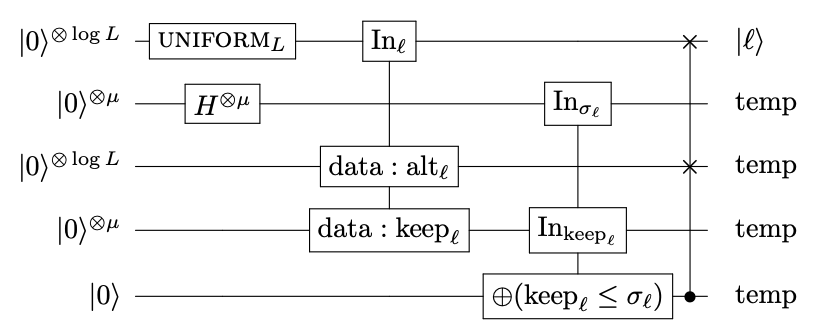

With a small circuit instance like this, we can actually run the circuit simulator and get the preped state. Since Alias Sampling will produce a $|temp\rangle$ state entangled with the desired preped state, we can verify this by collecting the probability (amplitude square) of the preped state:

In [9]:
probs = []
for i in range(len(coeffs)):
    probs.append(target_reg.peek_read_probability(i))
print(probs)

[0.05468750000000001, 0.32812500000000006, 0.19531250000000003, 0.13281250000000003, 0.007812500000000002, 0.007812500000000002, 0.0, 0.27343750000000006]


Now let's mannually compute the 2-norm difference between the preped state generate by the quantum circuit simulator and the input:

In [10]:
preped_state = [np.sqrt(c) for c in probs]
print(l2_norm_diff(preped_state, l2_normalize(coeffs)))
_, _, numerical_2_norm_diff = alias_sampling_get_b_from_epsilon(coeffs, epsilon, return_theory_bound_and_actual_diff=True)
print(numerical_2_norm_diff)

0.03697982148736101
0.03697982148736101


We can see that it exactly matches the diff result computed by the `alias_sampling_get_b_from_epsilon()` in the numerical way (up to floating point error).